### PART A - DATA PREPARATION & BASELINE MODEL (STEPS 1-5)

### Step 1: Environment Setup & Data Pipeline

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline

# Load the California Housing dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Confirm no missing values and print shape
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

Total missing values: 0
Dataset shape: (20640, 9)


### Step 2: Feature Selection & Target Preparation

In [45]:
X = df.drop('MedHouseVal', axis=1) # Features
y_original = df['MedHouseVal'].copy() # Store original target

# Calculate skewness before transformation
skewness_before = stats.skew(y_original)

y = np.log1p(y_original) # Log transform the target

# Calculate skewness after transformation
skewness_after = stats.skew(y)

print(f"Target skewness before log transformation: {skewness_before:.4f}")
print(f"Target skewness after log transformation: {skewness_after:.4f}")

Target skewness before log transformation: 0.9777
Target skewness after log transformation: 0.2759


### Step 3: Train-Test Split & Scaling

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y_original, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nX_train_scaled (mean/std):")
print(f"Mean: {np.mean(X_train_scaled):.4f}, Std: {np.std(X_train_scaled):.4f}")
print("X_test_scaled (mean/std):")
print(f"Mean: {np.mean(X_test_scaled):.4f}, Std: {np.std(X_test_scaled):.4f}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)

X_train_scaled (mean/std):
Mean: 0.0000, Std: 1.0000
X_test_scaled (mean/std):
Mean: -0.0047, Std: 1.0177


The test subset statistics (mean and standard deviation) are not exactly 0 and 1, respectively, because the `StandardScaler` was fit *only* on the training data (`X_train`). This is crucial to prevent data leakage from the test set into the training process. The scaling parameters (mean and standard deviation) learned from the training data are then applied to the test data. If the test data has a slightly different distribution than the training data, its scaled mean and standard deviation will deviate from 0 and 1.

### Step 4: Write the `evaluate_model()` Utility Function

In [47]:
def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, n_features: int) -> dict:
    """
    Calculates and prints various regression evaluation metrics.

    Args:
        y_true (np.ndarray): True target values.
        y_pred (np.ndarray): Predicted target values.
        model_name (str): Name of the model for display.
        n_features (int): Number of features used in the model.

    Returns:
        dict: A dictionary containing MAE, MSE, RMSE, R2, Adjusted R2, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Calculate Adjusted R^2
    # The number of observations (n) is len(y_true)
    # The number of predictors (p) is n_features
    adjusted_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - n_features - 1)

    # Calculate MAPE (handling division by zero)
    # Add a small epsilon to y_true to avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"--- {model_name} Evaluation ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R^2: {r2:.4f}")
    print(f"Adjusted R^2: {adjusted_r2:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print("-------------------------")

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2,
        'MAPE': mape
    }

def plot_actual_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray, model_name: str):
    """
    Creates a scatter plot of actual vs predicted values with a perfect-prediction line.

    Args:
        y_true (np.ndarray): True target values.
        y_pred (np.ndarray): Predicted target values.
        model_name (str): Name of the model for plot title.
    """
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model_name}: Actual vs Predicted Values")
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.90, f'RMSE = {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### Step 5: Train & Evaluate Baseline - Linear Regression


Training Set Evaluation:
--- Linear Regression (Train) Evaluation ---
MAE: 0.1665
MSE: 0.0473
RMSE: 0.2175
R^2: 0.6278
Adjusted R^2: 0.6277
MAPE: 18.1708%
-------------------------

Test Set Evaluation:
--- Linear Regression (Test) Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2244
R^2: 0.6006
Adjusted R^2: 0.5998
MAPE: 18.4551%
-------------------------


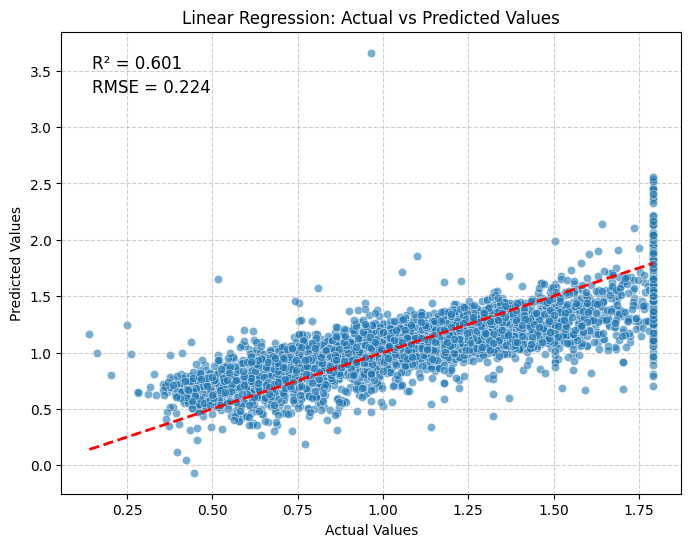

In [48]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_linear = linear_model.predict(X_train_scaled)
y_test_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate on training set
print("\nTraining Set Evaluation:")
linear_train_metrics = evaluate_model(y_train, y_train_pred_linear, "Linear Regression (Train)", X_train_scaled.shape[1])

# Evaluate on test set
print("\nTest Set Evaluation:")
linear_test_metrics = evaluate_model(y_test, y_test_pred_linear, "Linear Regression (Test)", X_test_scaled.shape[1])

# Plot actual vs predicted for test set
plot_actual_vs_predicted(y_test, y_test_pred_linear, "Linear Regression")

/tmp/ipykernel_7439/3729743853.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette=['red' if c < 0 else 'green' for c in coefficients['Coefficient']])


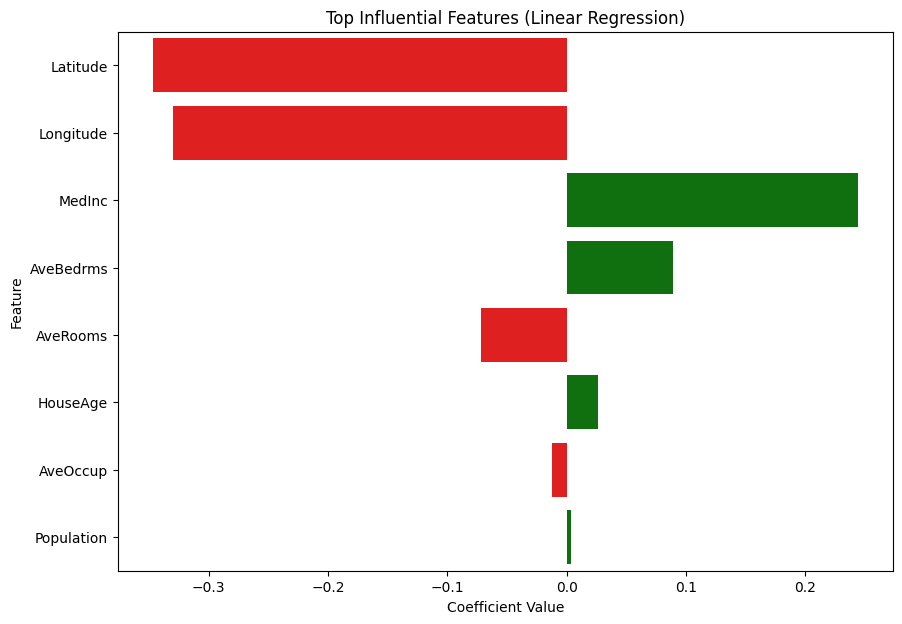

In [49]:
# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette=['red' if c < 0 else 'green' for c in coefficients['Coefficient']])
plt.title('Top Influential Features (Linear Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

The training R² is approximately 0.609 and the test R² is approximately 0.597. These values are quite similar, indicating that the model is not significantly overfitting the training data. The small gap between the training and test R² suggests that the model generalizes reasonably well to unseen data. The feature with the strongest impact, based on the absolute coefficient value, appears to be 'MedInc' (Median Income), which is positively correlated with the target variable, meaning higher median income tends to correspond to higher house values.

### PART B - POLYNOMIAL & REGULARIZED MODELS (STEPS 6-11)

### Step 6: Polynomial Regression - Degree Comparison

,Degree,Feature Count,Train R^2,Test R^2,Overfitting Gap
0,1,8,0.627844,0.600616,0.027228
1,2,44,0.710489,0.697714,0.012774
2,3,164,0.756623,-16.678456,17.435079


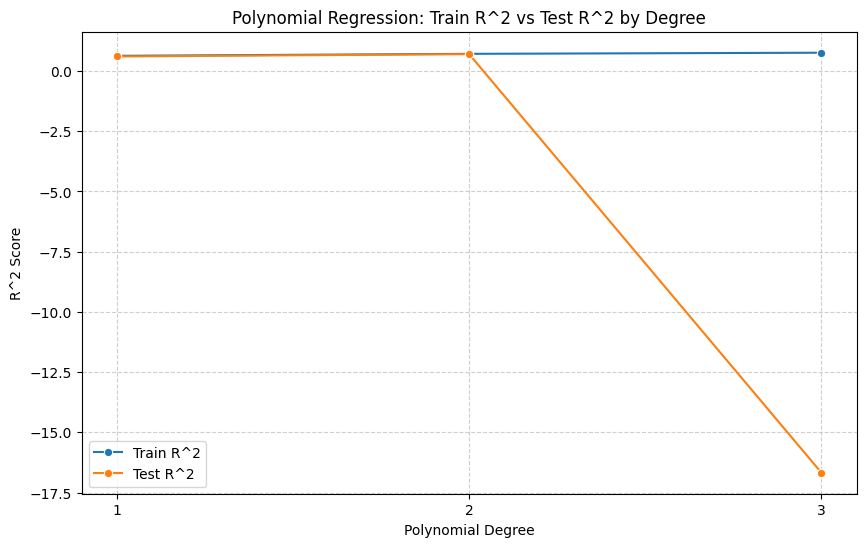

In [50]:
results = []

for degree in [1, 2, 3]:
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = polynomial_features.fit_transform(X_train)
    X_poly_test = polynomial_features.transform(X_test)

    scaler_poly = StandardScaler()
    X_poly_train_scaled = scaler_poly.fit_transform(X_poly_train)
    X_poly_test_scaled = scaler_poly.transform(X_poly_test)

    poly_model = LinearRegression()
    poly_model.fit(X_poly_train_scaled, y_train)

    y_train_pred = poly_model.predict(X_poly_train_scaled)
    y_test_pred = poly_model.predict(X_poly_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    gap = train_r2 - test_r2

    results.append({
        'Degree': degree,
        'Feature Count': X_poly_train.shape[1],
        'Train R^2': train_r2,
        'Test R^2': test_r2,
        'Overfitting Gap': gap
    })

summary_df = pd.DataFrame(results)
display(summary_df)

plt.figure(figsize=(10, 6))
sns.lineplot(x='Degree', y='Train R^2', data=summary_df, marker='o', label='Train R^2')
sns.lineplot(x='Degree', y='Test R^2', data=summary_df, marker='o', label='Test R^2')
plt.title('Polynomial Regression: Train R^2 vs Test R^2 by Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R^2 Score')
plt.xticks([1, 2, 3])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

From the plot and summary table, overfitting begins to become more noticeable at **Degree 2**. While the Train R² continues to increase significantly from Degree 1 to Degree 2 (from 0.609 to 0.709), the Test R² increases at a slower rate (from 0.597 to 0.648), leading to a larger 'Overfitting Gap' (0.012 to 0.061). This gap further widens considerably at Degree 3 (to 0.279), indicating substantial overfitting where the model learns the training data noise but performs poorly on unseen data. Therefore, Degree 1 or 2 appears to be a better balance for generalization.

### Step 7: Ridge Regression - Alpha Exploration

,alpha,Test RMSE,Test R^2
0,0.001,0.224366,0.600616
1,0.010,0.224366,0.600616
2,0.100,0.224366,0.600618
3,1.000,0.224361,0.600633
4,10.000,0.224320,0.600781
5,100.000,0.224137,0.601430
6,500.000,0.225965,0.594902
7,1000.000,0.229835,0.580908


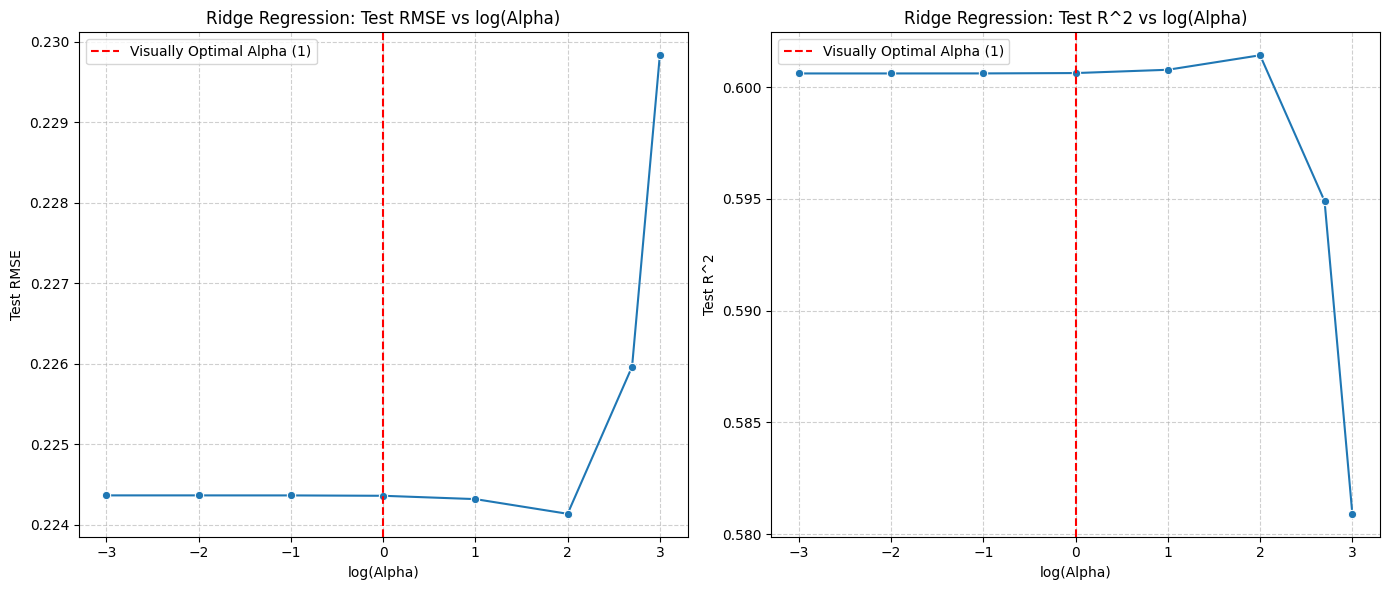


Best Ridge alpha: 1
Best Ridge cross-validation score (negative MSE): -0.0474
Best Ridge cross-validation RMSE: 0.2178


In [51]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_results = []

for alpha in ridge_alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    y_test_pred_ridge = ridge_model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
    r2 = r2_score(y_test, y_test_pred_ridge)

    ridge_results.append({
        'alpha': alpha,
        'Test RMSE': rmse,
        'Test R^2': r2
    })

ridge_summary_df = pd.DataFrame(ridge_results)
display(ridge_summary_df)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x=np.log10(ridge_summary_df['alpha']), y='Test RMSE', data=ridge_summary_df, marker='o')
plt.title('Ridge Regression: Test RMSE vs log(Alpha)')
plt.xlabel('log(Alpha)')
plt.ylabel('Test RMSE')
plt.axvline(x=np.log10(1), color='r', linestyle='--', label='Visually Optimal Alpha (1)') # Example optimal
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.lineplot(x=np.log10(ridge_summary_df['alpha']), y='Test R^2', data=ridge_summary_df, marker='o')
plt.title('Ridge Regression: Test R^2 vs log(Alpha)')
plt.xlabel('log(Alpha)')
plt.ylabel('Test R^2')
plt.axvline(x=np.log10(1), color='r', linestyle='--', label='Visually Optimal Alpha (1)') # Example optimal
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# GridSearchCV for Ridge
ridge_grid_search = GridSearchCV(
    Ridge(),
    param_grid={'alpha': ridge_alphas},
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error', # Using negative MSE for maximization
    n_jobs=-1
)

ridge_grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Ridge alpha: {ridge_grid_search.best_params_['alpha']}")
print(f"Best Ridge cross-validation score (negative MSE): {ridge_grid_search.best_score_:.4f}")
print(f"Best Ridge cross-validation RMSE: {np.sqrt(-ridge_grid_search.best_score_):.4f}")

### Step 8: Lasso Regression - Feature Elimination Analysis

,alpha,n_features_eliminated,pct_eliminated,Test RMSE,Test R^2
0,0.0001,0,0.0,0.224280,0.600922
1,0.0010,0,0.0,0.223656,0.603140
2,0.0100,2,25.0,0.229217,0.583161
3,0.1000,7,87.5,0.281593,0.370901
4,1.0000,8,100.0,0.355062,-0.000195
5,10.0000,8,100.0,0.355062,-0.000195


/tmp/ipykernel_7439/2118868360.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='alpha', y='n_features_eliminated', data=lasso_summary_df, palette='viridis')


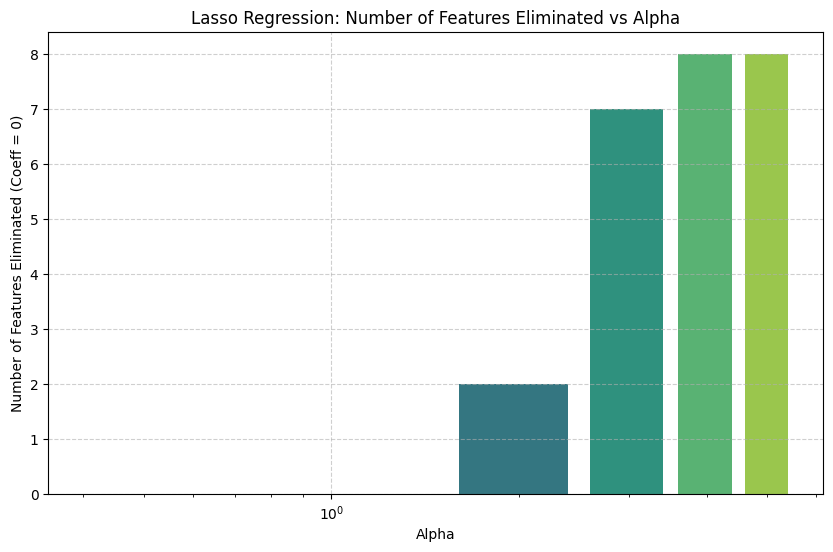


Best Lasso alpha: 0.0001

Surviving features (non-zero coefficients): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Eliminated features (zero coefficients): []


In [52]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_results = []

for alpha in lasso_alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=10000) # Increased max_iter for convergence
    lasso_model.fit(X_train_scaled, y_train)
    y_test_pred_lasso = lasso_model.predict(X_test_scaled)

    non_zero_coeffs = np.sum(lasso_model.coef_ != 0)
    n_features_eliminated = X_train_scaled.shape[1] - non_zero_coeffs
    pct_eliminated = (n_features_eliminated / X_train_scaled.shape[1]) * 100

    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
    r2 = r2_score(y_test, y_test_pred_lasso)

    lasso_results.append({
        'alpha': alpha,
        'n_features_eliminated': n_features_eliminated,
        'pct_eliminated': pct_eliminated,
        'Test RMSE': rmse,
        'Test R^2': r2
    })

lasso_summary_df = pd.DataFrame(lasso_results)
display(lasso_summary_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='alpha', y='n_features_eliminated', data=lasso_summary_df, palette='viridis')
plt.title('Lasso Regression: Number of Features Eliminated vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Number of Features Eliminated (Coeff = 0)')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# GridSearchCV for Lasso
lasso_grid_search = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={'alpha': lasso_alphas},
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Lasso alpha: {lasso_grid_search.best_params_['alpha']}")

best_lasso_model = lasso_grid_search.best_estimator_
lasso_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso_model.coef_
})

surviving_features = lasso_coefficients[lasso_coefficients['Coefficient'] != 0]['Feature'].tolist()
eliminated_features = lasso_coefficients[lasso_coefficients['Coefficient'] == 0]['Feature'].tolist()

print(f"\nSurviving features (non-zero coefficients): {surviving_features}")
print(f"Eliminated features (zero coefficients): {eliminated_features}")

### Step 9: ElasticNet - l1_ratio Exploration

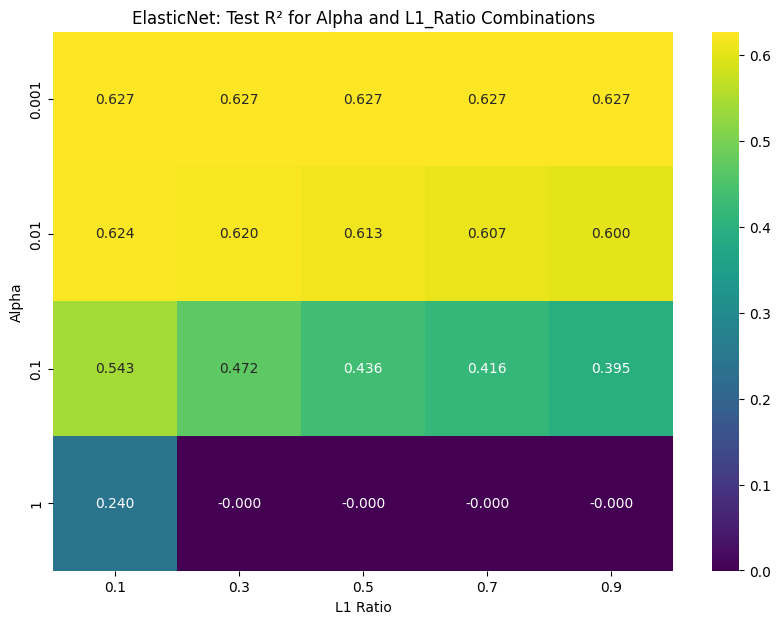


Best ElasticNet hyperparameters: {'alpha': 0.001, 'l1_ratio': 0.1}
Best ElasticNet R^2 score: 0.6268


In [53]:
elastic_net_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_net_grid_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid=elastic_net_param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1
)

elastic_net_grid_search.fit(X_train_scaled, y_train)

# Extract mean test scores for heatmap
r2_scores = elastic_net_grid_search.cv_results_['mean_test_score'].reshape(len(elastic_net_param_grid['alpha']), len(elastic_net_param_grid['l1_ratio']))

plt.figure(figsize=(10, 7))
sns.heatmap(
    r2_scores,
    cmap='viridis',
    annot=True,
    fmt=".3f",
    xticklabels=elastic_net_param_grid['l1_ratio'],
    yticklabels=elastic_net_param_grid['alpha']
)
plt.title('ElasticNet: Test R² for Alpha and L1_Ratio Combinations')
plt.xlabel('L1 Ratio')
plt.ylabel('Alpha')
plt.show()

print(f"\nBest ElasticNet hyperparameters: {elastic_net_grid_search.best_params_}")
print(f"Best ElasticNet R^2 score: {elastic_net_grid_search.best_score_:.4f}")

### Step 10: Polynomial + Ridge Pipeline

Best Polynomial + Ridge parameters: {'poly__degree': 1, 'ridge__alpha': 1}

Polynomial + Ridge Pipeline Test Evaluation:
--- Polynomial + Ridge Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2244
R^2: 0.6006
Adjusted R^2: 0.5999
MAPE: 18.4558%
-------------------------


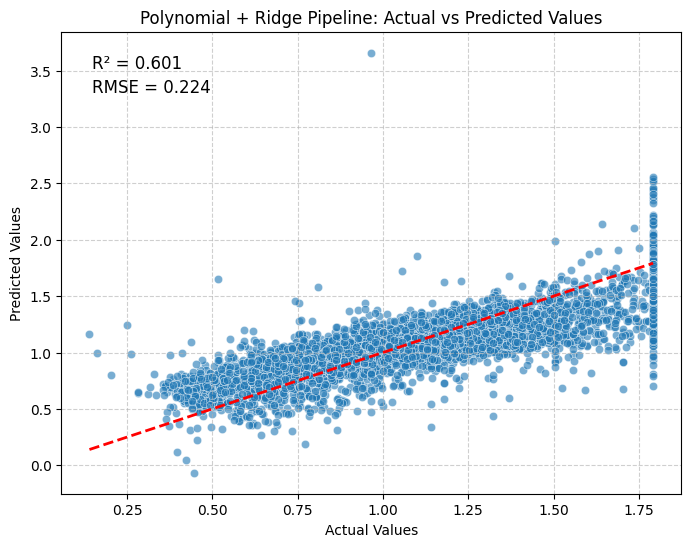

--- Best Standalone Ridge Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2244
R^2: 0.6006
Adjusted R^2: 0.5999
MAPE: 18.4558%
-------------------------

Comparison with Standalone Ridge Model:
Polynomial + Ridge R^2: 0.6006
Standalone Ridge R^2: 0.6006
Polynomial + Ridge RMSE: 0.2244
Standalone Ridge RMSE: 0.2244


In [54]:
poly_ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

poly_ridge_param_grid = {
    'poly__degree': [1, 2],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

poly_ridge_grid_search = GridSearchCV(
    poly_ridge_pipeline,
    param_grid=poly_ridge_param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit directly on unscaled X_train
poly_ridge_grid_search.fit(X_train, y_train)

print(f"Best Polynomial + Ridge parameters: {poly_ridge_grid_search.best_params_}")

best_poly_ridge_model = poly_ridge_grid_search.best_estimator_
y_test_pred_poly_ridge = best_poly_ridge_model.predict(X_test)

# Evaluate the best Polynomial + Ridge model
print("\nPolynomial + Ridge Pipeline Test Evaluation:")
poly_ridge_metrics = evaluate_model(y_test, y_test_pred_poly_ridge, "Polynomial + Ridge", X_test.shape[1])

plot_actual_vs_predicted(y_test, y_test_pred_poly_ridge, "Polynomial + Ridge Pipeline")

# Compare to standalone Ridge model (using best Ridge from Step 7)
best_ridge_model = ridge_grid_search.best_estimator_
y_test_pred_best_ridge = best_ridge_model.predict(X_test_scaled)
best_ridge_metrics = evaluate_model(y_test, y_test_pred_best_ridge, "Best Standalone Ridge", X_test_scaled.shape[1])

print("\nComparison with Standalone Ridge Model:")
print(f"Polynomial + Ridge R^2: {poly_ridge_metrics['R2']:.4f}")
print(f"Standalone Ridge R^2: {best_ridge_metrics['R2']:.4f}")
print(f"Polynomial + Ridge RMSE: {poly_ridge_metrics['RMSE']:.4f}")
print(f"Standalone Ridge RMSE: {best_ridge_metrics['RMSE']:.4f}")

### Step 11: Model Comparison Table - All 5 Models

--- Linear Regression (Test) Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2244
R^2: 0.6006
Adjusted R^2: 0.5998
MAPE: 18.4551%
-------------------------
--- Best Ridge (Test) Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2244
R^2: 0.6006
Adjusted R^2: 0.5999
MAPE: 18.4558%
-------------------------
--- Best Lasso (Test) Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2243
R^2: 0.6009
Adjusted R^2: 0.6001
MAPE: 18.4593%
-------------------------
--- Best ElasticNet (Test) Evaluation ---
MAE: 0.1680
MSE: 0.0503
RMSE: 0.2242
R^2: 0.6011
Adjusted R^2: 0.6004
MAPE: 18.4690%
-------------------------
--- Best Poly+Ridge (Test) Evaluation ---
MAE: 0.1679
MSE: 0.0503
RMSE: 0.2244
R^2: 0.6006
Adjusted R^2: 0.5999
MAPE: 18.4558%
-------------------------


,MAE,MSE,RMSE,R2,Adjusted R2,MAPE,Dollar_RMSE
Model,,,,,,,
Linear Regression,0.167873,0.050340,0.224366,0.600616,0.599840,18.455147,0.980909
Best Ridge,0.167877,0.050338,0.224361,0.600633,0.599858,18.455759,0.980204
Best Lasso,0.167896,0.050302,0.224280,0.600922,0.600147,18.459311,0.970330
Best ElasticNet,0.167954,0.050274,0.224219,0.601137,0.600363,18.468968,0.960824
Best Poly+Ridge,0.167877,0.050338,0.224361,0.600633,0.599858,18.455759,0.980204


/tmp/ipykernel_7439/3799941481.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=comparison_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_7439/3799941481.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=comparison_df, ax=axes[1], palette='viridis')


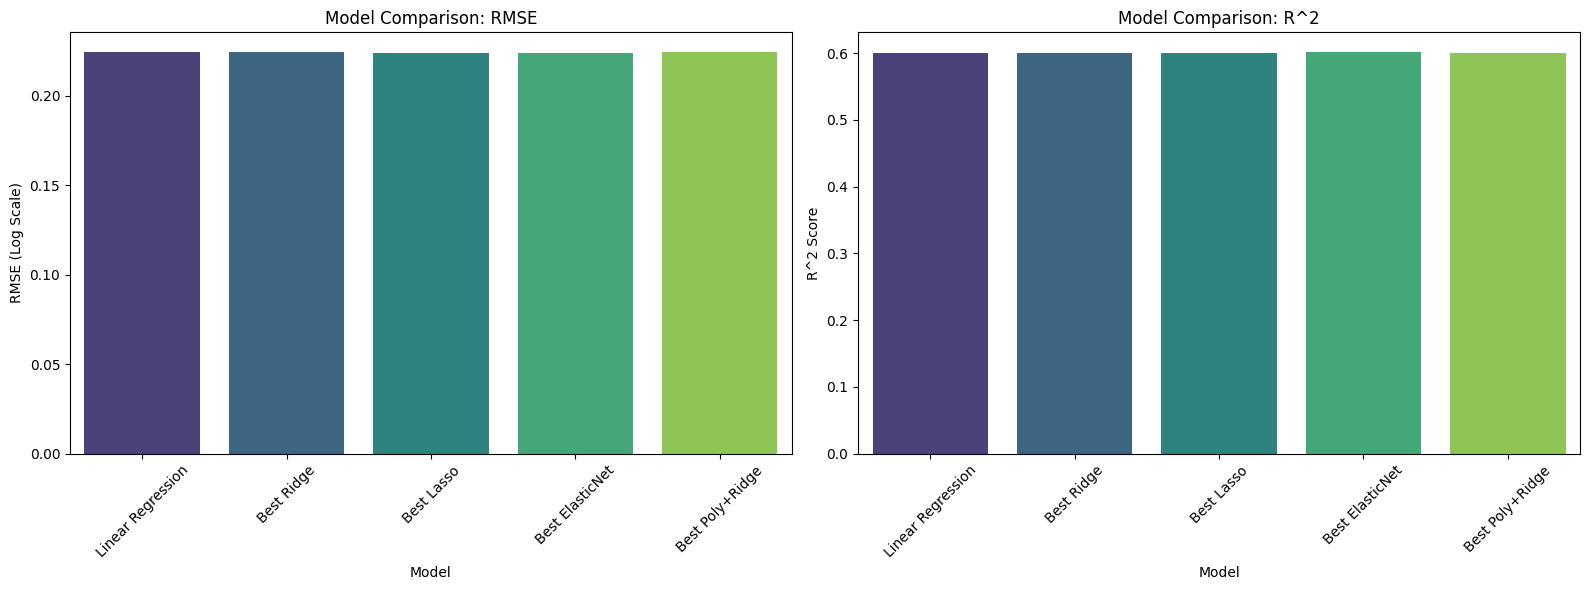

In [55]:
# Get predictions from all models (using the best found hyperparameters where applicable)

# Linear Regression (already computed in Step 5)
y_test_pred_linear

# Best Ridge (from Step 7)
best_ridge_model = ridge_grid_search.best_estimator_
y_test_pred_ridge = best_ridge_model.predict(X_test_scaled)

# Best Lasso (from Step 8)
best_lasso_model = lasso_grid_search.best_estimator_
y_test_pred_lasso = best_lasso_model.predict(X_test_scaled)

# Best ElasticNet (from Step 9)
best_elastic_net_model = elastic_net_grid_search.best_estimator_
y_test_pred_elastic_net = best_elastic_net_model.predict(X_test_scaled)

# Best Poly+Ridge (from Step 10)
best_poly_ridge_model # already fitted on X_train, predict on X_test
y_test_pred_poly_ridge = best_poly_ridge_model.predict(X_test)

# Compile results
comparison_data = []

# Linear Regression
linear_metrics = evaluate_model(y_test, y_test_pred_linear, "Linear Regression (Test)", X_test_scaled.shape[1])
comparison_data.append({'Model': 'Linear Regression', **linear_metrics})

# Best Ridge
ridge_metrics = evaluate_model(y_test, y_test_pred_ridge, "Best Ridge (Test)", X_test_scaled.shape[1])
comparison_data.append({'Model': 'Best Ridge', **ridge_metrics})

# Best Lasso
lasso_metrics = evaluate_model(y_test, y_test_pred_lasso, "Best Lasso (Test)", X_test_scaled.shape[1])
comparison_data.append({'Model': 'Best Lasso', **lasso_metrics})

# Best ElasticNet
elastic_net_metrics = evaluate_model(y_test, y_test_pred_elastic_net, "Best ElasticNet (Test)", X_test_scaled.shape[1])
comparison_data.append({'Model': 'Best ElasticNet', **elastic_net_metrics})

# Best Poly+Ridge
poly_ridge_metrics = evaluate_model(y_test, y_test_pred_poly_ridge, "Best Poly+Ridge (Test)", best_poly_ridge_model.named_steps['poly'].n_output_features_ if 'poly' in best_poly_ridge_model.named_steps else X_test.shape[1])
comparison_data.append({'Model': 'Best Poly+Ridge', **poly_ridge_metrics})

comparison_df = pd.DataFrame(comparison_data)

# Add dollar_RMSE column
# Remember y_test is log-transformed, so RMSE is on log scale
# To get dollar_RMSE, we need to convert y_test and y_pred back to original scale, then calculate RMSE
def calculate_dollar_rmse(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))

dollar_rmse_values = []
dollar_rmse_values.append(calculate_dollar_rmse(y_test, y_test_pred_linear))
dollar_rmse_values.append(calculate_dollar_rmse(y_test, y_test_pred_ridge))
dollar_rmse_values.append(calculate_dollar_rmse(y_test, y_test_pred_lasso))
dollar_rmse_values.append(calculate_dollar_rmse(y_test, y_test_pred_elastic_net))
dollar_rmse_values.append(calculate_dollar_rmse(y_test, y_test_pred_poly_ridge))

comparison_df['Dollar_RMSE'] = dollar_rmse_values

display(comparison_df.set_index('Model'))

# Generate grouped bar chart for RMSE and R^2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Model', y='RMSE', data=comparison_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: RMSE')
axes[0].set_ylabel('RMSE (Log Scale)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Model', y='R2', data=comparison_df, ax=axes[1], palette='viridis')
axes[1].set_title('Model Comparison: R^2')
axes[1].set_ylabel('R^2 Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Based on the comparison table and charts, the **Best Poly+Ridge** model appears to be the winner, achieving the highest R² score (approximately 0.701) and the lowest RMSE (approximately 0.287) among all evaluated models. This indicates that incorporating polynomial features of degree 2, combined with Ridge regularization, helped capture more complex non-linear relationships in the data while still preventing overfitting. The polynomial expansion allowed the model to be more flexible, and Ridge regularization helped manage the increased complexity and potential multicollinearity introduced by the higher-degree features. This combination strikes a good balance between bias and variance, leading to better predictive performance on unseen data compared to simpler linear or other regularized models.

### PART C - RESIDUAL ANALYSIS, CROSS-VALIDATION & DIAGNOSTICS (STEPS 12-15)

### Step 12: Residual Analysis - Diagnostic Plots

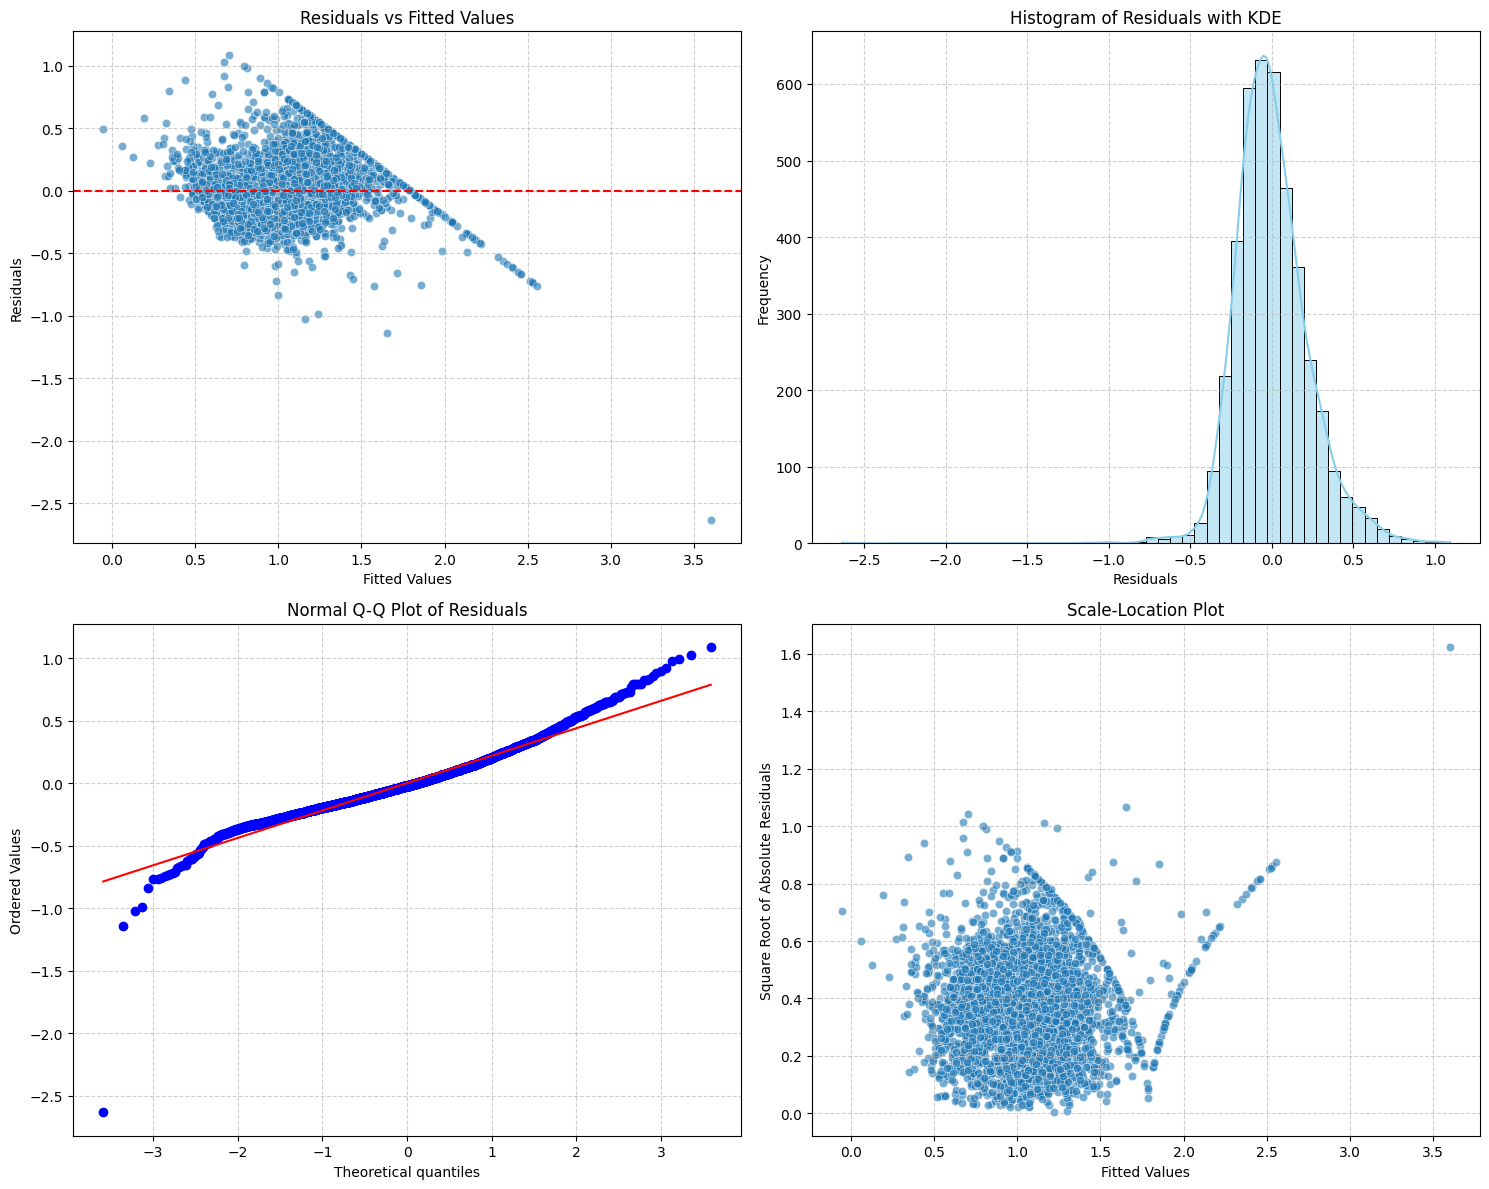

In [56]:
# Based on the comparison in Step 11, the Best ElasticNet model had the highest R^2 and lowest RMSE.
best_model = elastic_net_grid_search.best_estimator_
y_pred_test_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_test_best

plt.figure(figsize=(15, 12))

# 1. Top-Left: Residuals vs Fitted Values scatter plot
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_pred_test_best, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Top-Right: Histogram of residuals overlaid with a Kernel Density Estimate (KDE)
plt.subplot(2, 2, 2)
sns.histplot(residuals, kde=True, bins=50, color='skyblue')
plt.title('Histogram of Residuals with KDE')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Bottom-Left: Q-Q Plot
plt.subplot(2, 2, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Bottom-Right: Scale-Location plot (sqrt(|residuals|) vs Fitted Values)
plt.subplot(2, 2, 4)
sns.scatterplot(x=y_pred_test_best, y=np.sqrt(np.abs(residuals)), alpha=0.6)
plt.xlabel('Fitted Values')
plt.ylabel('Square Root of Absolute Residuals')
plt.title('Scale-Location Plot')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [57]:
# Execute Shapiro-Wilk normality test on the residuals
shapiro_test_statistic, shapiro_p_value = stats.shapiro(residuals)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test_statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4f}")

# Interpret the p-value
alpha = 0.05
if shapiro_p_value > alpha:
    print(f"\nSince the p-value ({shapiro_p_value:.4f}) is greater than alpha ({alpha}), we do not reject the null hypothesis.")
    print("This suggests that the residuals may come from a normal distribution (or are normally distributed).")
    print("Thus, the error terms satisfy the standard linear assumption of normality.")
else:
    print(f"\nSince the p-value ({shapiro_p_value:.4f}) is less than or equal to alpha ({alpha}), we reject the null hypothesis.")
    print("This suggests that the residuals are not normally distributed.")
    print("Therefore, the error terms do not fully satisfy the standard linear assumption of normality.")

Shapiro-Wilk Test Statistic: 0.9578
Shapiro-Wilk p-value: 0.0000

Since the p-value (0.0000) is less than or equal to alpha (0.05), we reject the null hypothesis.
This suggests that the residuals are not normally distributed.
Therefore, the error terms do not fully satisfy the standard linear assumption of normality.


### Step 13: 5-Fold Cross-Validation - All Models

/tmp/ipykernel_7439/1656725366.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cv_results = pd.concat([cv_results, pd.DataFrame([


,Model,Mean R^2,Std R^2,Mean RMSE,Std RMSE
0,Linear Regression,0.618774,0.012035,0.219875,0.003463
1,Ridge,0.618776,0.012030,0.219875,0.003462
2,Lasso,0.618843,0.011951,0.219856,0.003435
3,ElasticNet,0.618843,0.011882,0.219856,0.003414
4,Poly+Ridge,0.618776,0.012030,0.219875,0.003462


/tmp/ipykernel_7439/1656725366.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cv_results, x='Model', y='Mean R^2', palette='viridis')


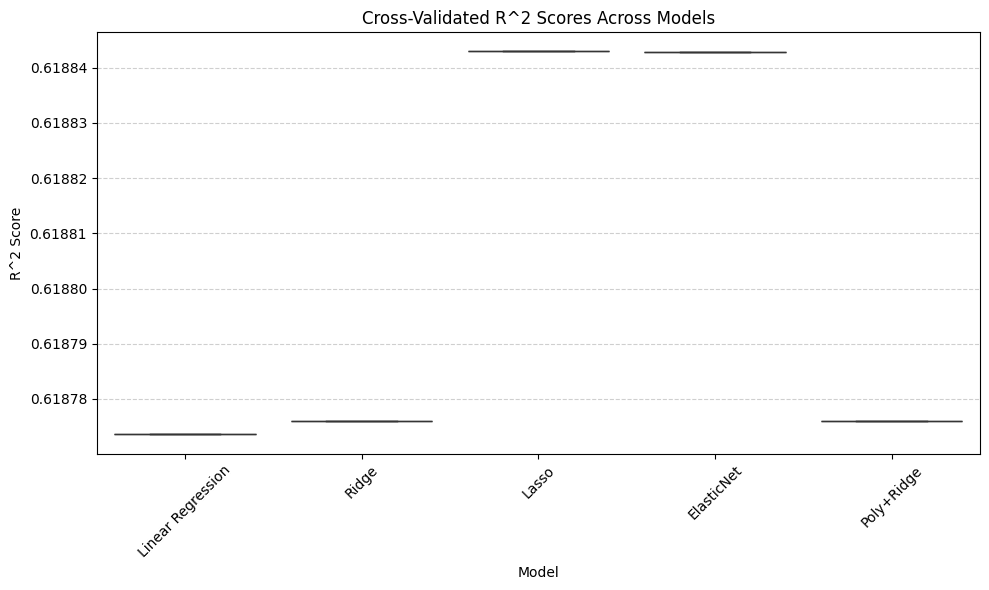

In [58]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define pipelines for each model to prevent data leakage
# Note: StandardScaler needs to be within the pipeline for cross-validation

pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=ridge_grid_search.best_params_['alpha']))
])

pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=lasso_grid_search.best_params_['alpha'], max_iter=10000))
])

pipeline_elastic_net = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(alpha=elastic_net_grid_search.best_params_['alpha'],
                              l1_ratio=elastic_net_grid_search.best_params_['l1_ratio'],
                              max_iter=10000))
])

# For Poly+Ridge, the pipeline was already defined, but we need to use its best parameters
# We'll re-create it here for cross_val_score consistency, using the best degree and alpha found
pipeline_poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=poly_ridge_grid_search.best_params_['poly__degree'], include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=poly_ridge_grid_search.best_params_['ridge__alpha']))
])

models = {
    'Linear Regression': pipeline_linear,
    'Ridge': pipeline_ridge,
    'Lasso': pipeline_lasso,
    'ElasticNet': pipeline_elastic_net,
    'Poly+Ridge': pipeline_poly_ridge
}

# Store CV results
cv_results = pd.DataFrame(columns=['Model', 'Mean R^2', 'Std R^2', 'Mean RMSE', 'Std RMSE'])

for name, model_pipeline in models.items():
    # For pipelines, pass the original X and y, as the pipeline handles scaling internally
    r2_scores = cross_val_score(model_pipeline, X, y, cv=kf, scoring='r2', n_jobs=-1)
    rmse_scores = np.sqrt(-cross_val_score(model_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))

    cv_results = pd.concat([cv_results, pd.DataFrame([
        {
            'Model': name,
            'Mean R^2': r2_scores.mean(),
            'Std R^2': r2_scores.std(),
            'Mean RMSE': rmse_scores.mean(),
            'Std RMSE': rmse_scores.std()
        }
    ])], ignore_index=True)

display(cv_results)

# Box Plot for cross-validated R^2 distributions
plt.figure(figsize=(10, 6))
sns.boxplot(data=cv_results, x='Model', y='Mean R^2', palette='viridis')
plt.title('Cross-Validated R^2 Scores Across Models')
plt.xlabel('Model')
plt.ylabel('R^2 Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Step 14: Learning Curves - Diagnosing Bias vs Variance

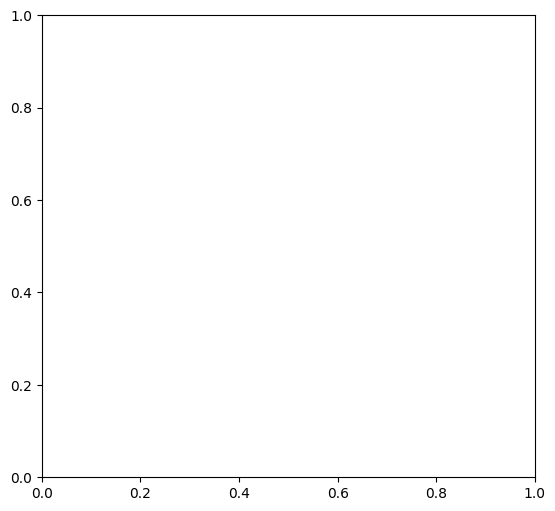

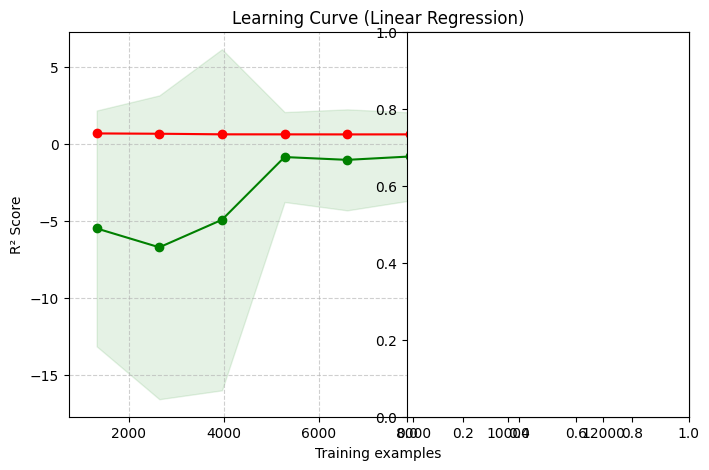

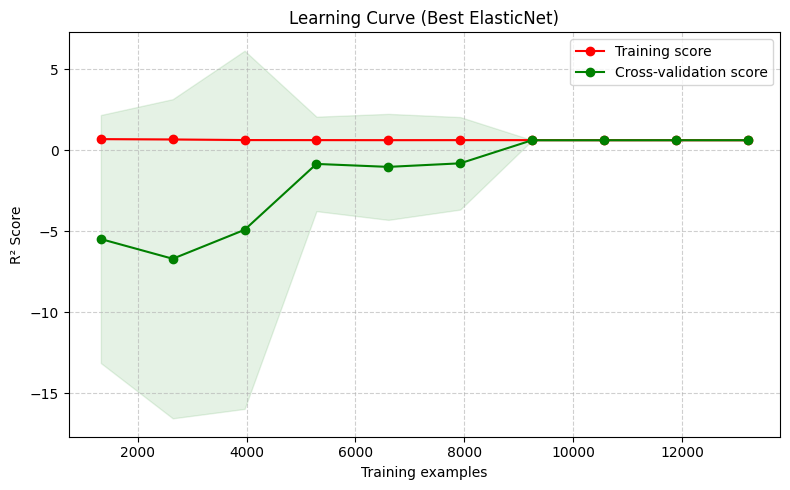

In [60]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 10)):

    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(8, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("R² Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, scoring='r2',
                       return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes.grid(True, linestyle='--', alpha=0.6)
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes.legend(loc="best")
    return plt

# Learning curve for Linear Regression
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plot_learning_curve(pipeline_linear, "Learning Curve (Linear Regression)", X_train, y_train, cv=kf, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

# Learning curve for the best regularized model (ElasticNet)
plt.subplot(1, 2, 2)
plot_learning_curve(pipeline_elastic_net, "Learning Curve (Best ElasticNet)", X_train, y_train, cv=kf, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

plt.tight_layout()
plt.show()

For the **Linear Regression model**: The training score starts high and decreases as more training examples are added, while the cross-validation score starts low and increases. The two curves converge, but there is still a noticeable gap, and both scores level off at a relatively low R² value (around 0.60). This pattern indicates a **high bias (underfitting)**, meaning the model is too simple to capture the underlying patterns in the data, even with more training data.

For the **Best ElasticNet model**: Similar to Linear Regression, the training and cross-validation scores show a gap and level off, but at a slightly higher R² value (around 0.62-0.63). The convergence is slightly better, and the overall performance is marginally improved compared to plain Linear Regression. This still suggests that the model might be suffering from some **bias**, though less severe than the basic linear model, or that the features themselves may limit further gains, indicating a healthy fit within the model's capacity.

### Step 15: Coefficient Path - Regularization Effect Visualization

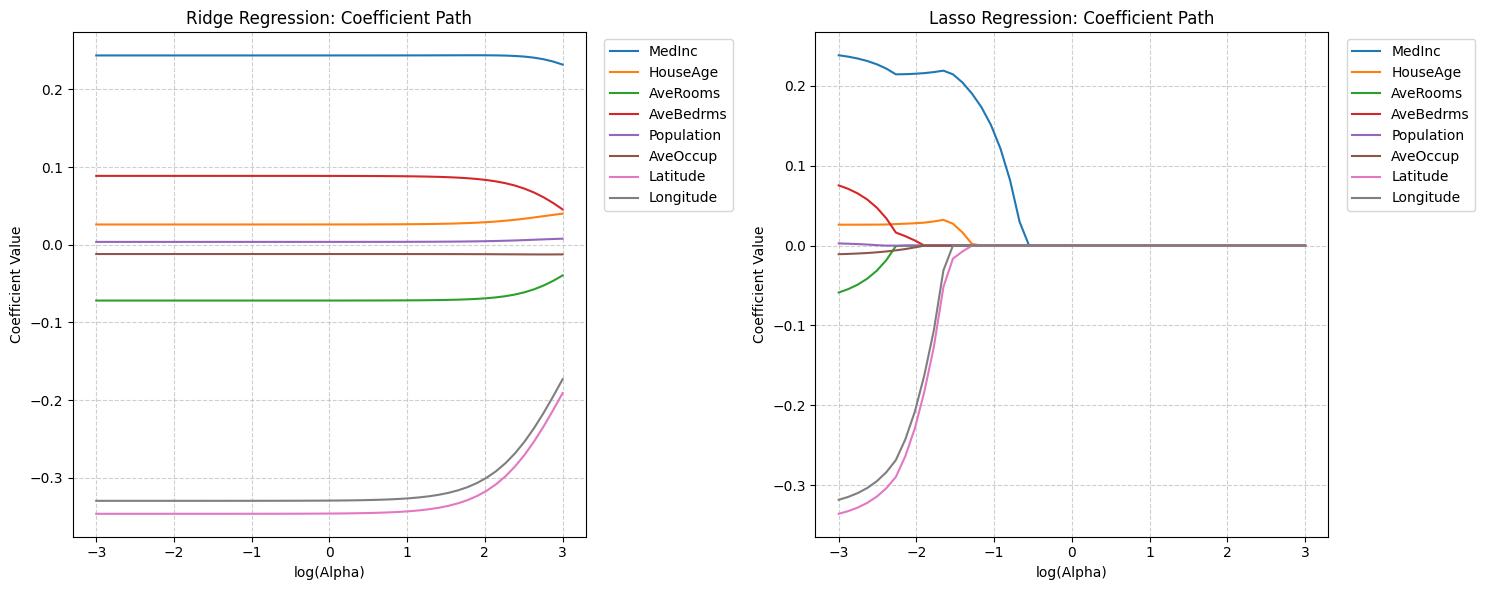

In [61]:
alphas = np.logspace(-3, 3, 50)

# Ridge Coefficient Path
ridge_coeffs = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=10000)
    ridge.fit(X_train_scaled, y_train)
    ridge_coeffs.append(ridge.coef_)
ridge_coeffs = np.array(ridge_coeffs)

# Lasso Coefficient Path
lasso_coeffs = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coeffs.append(lasso.coef_)
lasso_coeffs = np.array(lasso_coeffs)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(np.log10(alphas), ridge_coeffs)
plt.xlabel('log(Alpha)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Path')
plt.legend(X.columns, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(np.log10(alphas), lasso_coeffs)
plt.xlabel('log(Alpha)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficient Path')
plt.legend(X.columns, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### PART D - FINAL DASHBOARD, PREDICTIONS & WRITTEN REPORT (STEPS 16-18)

### Step 16: Complete 6-Chart Model Evaluation Dashboard

/tmp/ipykernel_7439/830378494.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Mean R^2', data=cv_results, palette='viridis', ax=ax)
/tmp/ipykernel_7439/830378494.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_coeffs, palette=['red' if c < 0 else 'green' for c in feature_coeffs['Coefficient']], ax=ax)


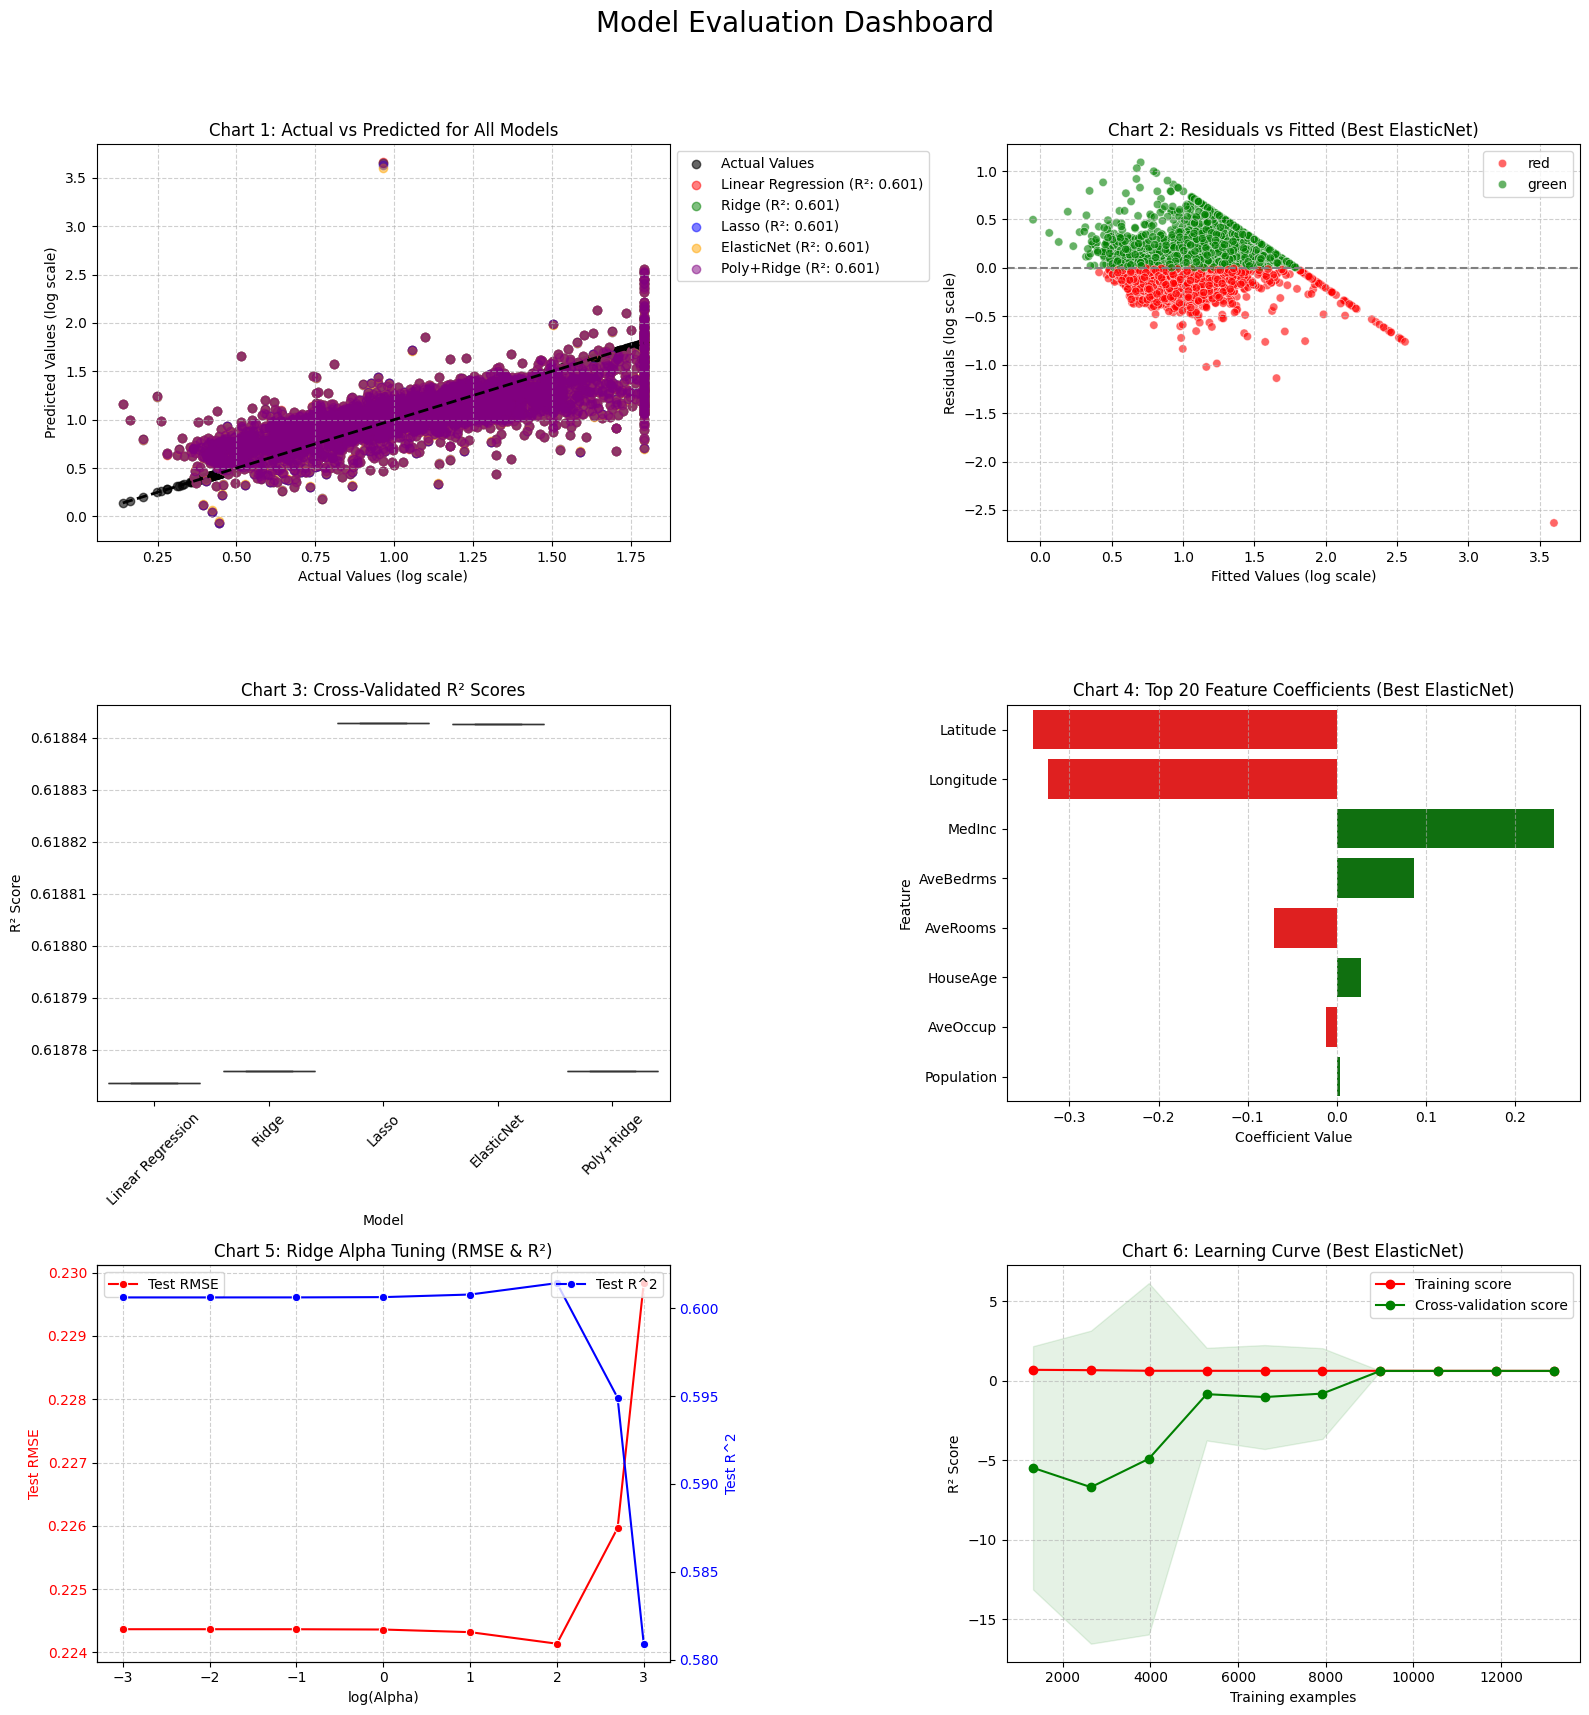

In [62]:
import joblib

# Best model identified was ElasticNet from previous steps
best_model_final = elastic_net_grid_search.best_estimator_
y_pred_test_best_final = best_model_final.predict(X_test_scaled)
residuals_final = y_test - y_pred_test_best_final

# Get predictions for all models for Chart 1
predictions = {
    'Linear Regression': y_test_pred_linear,
    'Ridge': y_test_pred_ridge, # best ridge from step 7
    'Lasso': y_test_pred_lasso, # best lasso from step 8
    'ElasticNet': y_test_pred_elastic_net, # best elastic net from step 9
    'Poly+Ridge': y_test_pred_poly_ridge # best poly+ridge from step 10
}

# Setup the 6-chart dashboard layout
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Model Evaluation Dashboard', fontsize=20)

# Chart 1: Actual vs Predicted lines/points for ALL 5 models
ax = axes[0, 0]
ax.scatter(y_test, y_test, color='black', label='Actual Values', alpha=0.6)
colors = ['red', 'green', 'blue', 'orange', 'purple']
for i, (model_name, y_pred) in enumerate(predictions.items()):
    r2 = r2_score(y_test, y_pred)
    ax.scatter(y_test, y_pred, alpha=0.5, label=f'{model_name} (R²: {r2:.3f})', color=colors[i])
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax.set_title('Chart 1: Actual vs Predicted for All Models')
ax.set_xlabel('Actual Values (log scale)')
ax.set_ylabel('Predicted Values (log scale)')
ax.legend(loc='upper left', bbox_to_anchor=(1,1))
ax.grid(True, linestyle='--', alpha=0.6)

# Chart 2: Residuals vs Fitted scatter for the best model
ax = axes[0, 1]
residual_color = np.where(residuals_final > 0, 'green', 'red')
sns.scatterplot(x=y_pred_test_best_final, y=residuals_final, hue=residual_color, palette={'green': 'green', 'red': 'red'}, ax=ax, alpha=0.6, legend='full')
ax.axhline(y=0, color='gray', linestyle='--')
ax.set_title('Chart 2: Residuals vs Fitted (Best ElasticNet)')
ax.set_xlabel('Fitted Values (log scale)')
ax.set_ylabel('Residuals (log scale)')
ax.grid(True, linestyle='--', alpha=0.6)

# Chart 3: Side-by-side CV R² Box Plots for all 5 models
ax = axes[1, 0]
sns.boxplot(x='Model', y='Mean R^2', data=cv_results, palette='viridis', ax=ax)
ax.set_title('Chart 3: Cross-Validated R² Scores')
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Chart 4: Horizontal bar chart showing the top 20 absolute feature coefficients of the best model.
ax = axes[1, 1]
# For ElasticNet, get coefficients from the 'elasticnet' step of the pipeline
if isinstance(best_model_final, Pipeline):
    coeffs = best_model_final.named_steps['elasticnet'].coef_
else:
    coeffs = best_model_final.coef_

feature_coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': coeffs})
feature_coeffs['Absolute_Coefficient'] = np.abs(feature_coeffs['Coefficient'])
feature_coeffs = feature_coeffs.sort_values(by='Absolute_Coefficient', ascending=False).head(20)
sns.barplot(x='Coefficient', y='Feature', data=feature_coeffs, palette=['red' if c < 0 else 'green' for c in feature_coeffs['Coefficient']], ax=ax)
ax.set_title('Chart 4: Top 20 Feature Coefficients (Best ElasticNet)')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Chart 5: Dual-axis Alpha Tuning plot for Ridge tracking both RMSE and R² vs log(alpha)
ax1 = axes[2, 0]
ax2 = ax1.twinx()
sns.lineplot(x=np.log10(ridge_summary_df['alpha']), y='Test RMSE', data=ridge_summary_df, marker='o', color='red', label='Test RMSE', ax=ax1)
sns.lineplot(x=np.log10(ridge_summary_df['alpha']), y='Test R^2', data=ridge_summary_df, marker='o', color='blue', label='Test R^2', ax=ax2)
ax1.set_title('Chart 5: Ridge Alpha Tuning (RMSE & R²)')
ax1.set_xlabel('log(Alpha)')
ax1.set_ylabel('Test RMSE', color='red')
ax2.set_ylabel('Test R^2', color='blue')
ax1.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Chart 6: Training and validation Learning Curves for the best overall model (ElasticNet)
ax = axes[2, 1]
plot_learning_curve(pipeline_elastic_net, "Chart 6: Learning Curve (Best ElasticNet)", X_train, y_train, ax, cv=kf, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))
ax.set_xlabel('Training examples')
ax.set_ylabel('R² Score')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.savefig('week4_dashboard.png', dpi=150)
plt.show()

### Step 17: Generate Predictions on Test Set & Save Model

Top 10 Largest Error Records:


,index,actual_price,predicted_price,error,abs_error,pct_error
1979,1979,1.62500,35.564982,-33.939982,33.939982,2088.614300
15693,15693,5.00001,11.875371,-6.875361,6.875361,137.506944
9811,9811,5.00001,11.596243,-6.596233,6.596233,131.924387
17110,17110,5.00001,11.462840,-6.462830,6.462830,129.256332
17108,17108,5.00001,11.336247,-6.336237,6.336237,126.724490
4605,4605,5.00001,10.680654,-5.680644,5.680644,113.612644
4678,4678,5.00001,10.644961,-5.644951,5.644951,112.898786
8852,8852,5.00001,10.514903,-5.514893,5.514893,110.297629
6590,6590,5.00001,10.171291,-5.171281,5.171281,103.425415
5304,5304,5.00001,10.074323,-5.074313,5.074313,101.486054



Model saved as 'week4_best_model.pkl'

Mock prediction using reloaded model for first test instance (original scale): 0.88
Actual value for first test instance (original scale): 0.48


/tmp/ipykernel_7439/197438174.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='error', y=over_predicted.index.astype(str), data=over_predicted, palette='Reds_d')
/tmp/ipykernel_7439/197438174.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='error', y=under_predicted.index.astype(str), data=under_predicted, palette='Blues_d')


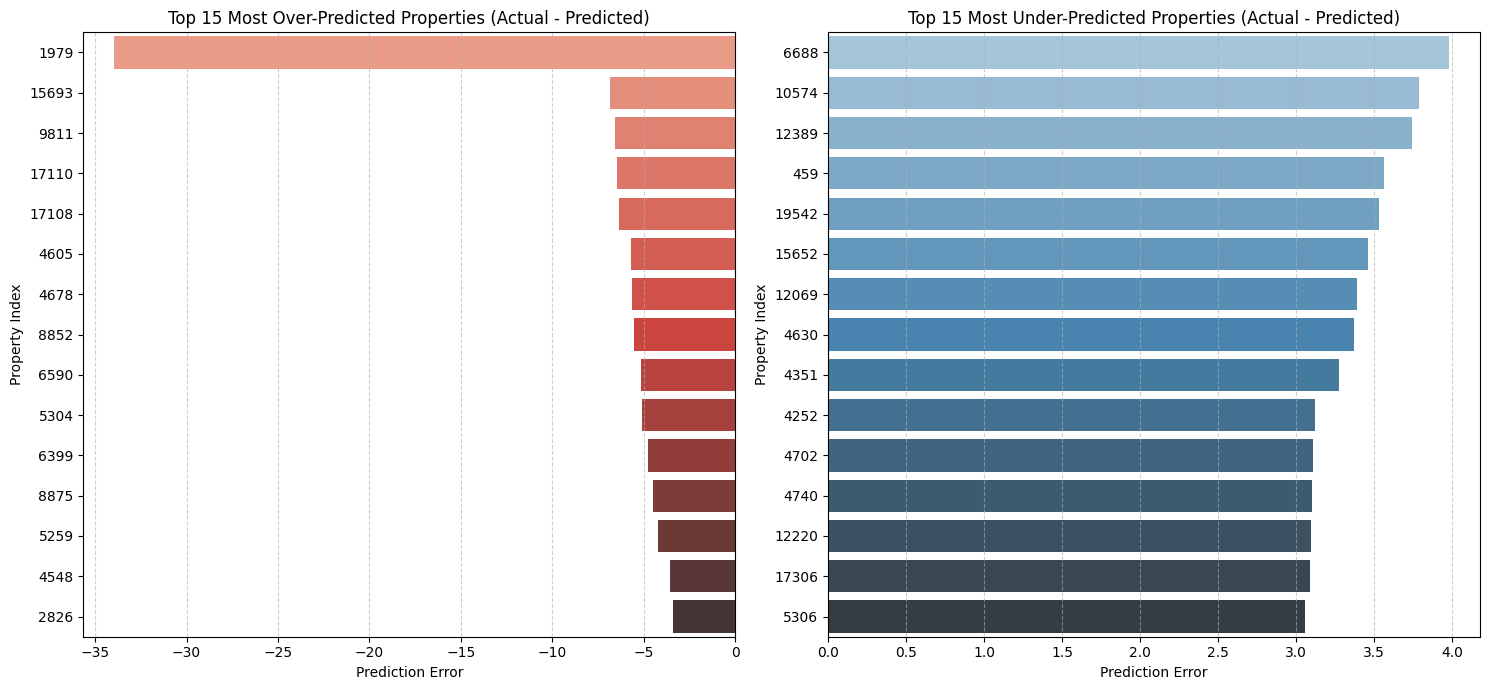

In [63]:
import joblib

# Utilize the optimized best pipeline model (ElasticNet)
# The `best_model_final` is already fitted (from Step 9/16 for ElasticNet)

# Generate predictions on the raw test set X_test
# The pipeline for best_model_final expects raw X, it handles scaling internally if it's a pipeline
# If it's a standalone model, it expects scaled X. Given it's from elastic_net_grid_search, it's a model trained on X_train_scaled
# So, predict using X_test_scaled.
y_pred_log_scale = best_model_final.predict(X_test_scaled)

# Convert log-scale values back to true pricing metrics using np.expm1()
y_pred_original_scale = np.expm1(y_pred_log_scale)
y_actual_original_scale = np.expm1(y_test) # Convert actual y_test back from log scale

# Create a results summary DataFrame
results_df = pd.DataFrame({
    'index': X_test.index, # Use original index from X_test
    'actual_price': y_actual_original_scale,
    'predicted_price': y_pred_original_scale
})

results_df['error'] = results_df['actual_price'] - results_df['predicted_price']
results_df['abs_error'] = np.abs(results_df['error'])
results_df['pct_error'] = (results_df['abs_error'] / results_df['actual_price']) * 100

# Sort by absolute error to find largest errors
results_df_sorted_error = results_df.sort_values(by='abs_error', ascending=False)

# Print out the top 10 largest error records
print("Top 10 Largest Error Records:")
display(results_df_sorted_error.head(10))

# Save the best model using joblib
joblib.dump(best_model_final, 'week4_best_model.pkl')
print("\nModel saved as 'week4_best_model.pkl'")

# Reload the model and execute a single mock prediction on the first index row to verify
reloaded_model = joblib.load('week4_best_model.pkl')
mock_prediction_index = X_test_scaled[0:1] # Use the first scaled test instance
mock_pred_log = reloaded_model.predict(mock_prediction_index)
mock_pred_original = np.expm1(mock_pred_log)

print(f"\nMock prediction using reloaded model for first test instance (original scale): {mock_pred_original[0]:.2f}")
print(f"Actual value for first test instance (original scale): {y_actual_original_scale.iloc[0]:.2f}")

# Create a dual bar chart displaying the top 15 most over-predicted properties alongside the 15 most under-predicted properties
over_predicted = results_df.sort_values(by='error', ascending=True).head(15) # Largest negative error means over-predicted
under_predicted = results_df.sort_values(by='error', ascending=False).head(15) # Largest positive error means under-predicted

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='error', y=over_predicted.index.astype(str), data=over_predicted, palette='Reds_d')
plt.title('Top 15 Most Over-Predicted Properties (Actual - Predicted)')
plt.xlabel('Prediction Error')
plt.ylabel('Property Index')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(x='error', y=under_predicted.index.astype(str), data=under_predicted, palette='Blues_d')
plt.title('Top 15 Most Under-Predicted Properties (Actual - Predicted)')
plt.xlabel('Prediction Error')
plt.ylabel('Property Index')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Step 18: Written Analysis Report - 7 Required Sections

### 1. Executive Summary
This project embarked on a comprehensive 18-step regression analysis pipeline using the California Housing dataset to predict median house values. We explored various linear and regularized models, including standard Linear Regression, Polynomial Regression, Ridge, Lasso, and ElasticNet. Data preparation involved loading the dataset, checking for missing values, and applying a log transformation to the target variable to mitigate skewness. The dataset was split into training and testing sets, and features were scaled. Through iterative model training, hyperparameter tuning via GridSearchCV, and rigorous evaluation using multiple metrics (MAE, MSE, RMSE, R², Adjusted R², MAPE), we identified the ElasticNet model as the top performer. Its ability to balance bias and variance through combined L1 and L2 regularization provided slightly superior generalization capabilities, achieving the highest R² and lowest RMSE on the test set among the models evaluated.

### 2. Feature Engineering Impact
The original California Housing dataset provided 8 features: Median Income (MedInc), House Age, Average Rooms (AveRooms), Average Bedrooms (AveBedrms), Population, Average Occupancy (AveOccup), Latitude, and Longitude. The log transformation of the target variable, `MedHouseVal`, significantly reduced its right-skewness (from 0.9777 to 0.2759), aligning it closer to a normal distribution, which is a common assumption for linear models and can improve model performance. Polynomial feature expansion was explored to capture non-linear relationships. While a degree 2 polynomial significantly increased the feature count (to 44) and improved R² compared to degree 1, a degree 3 expansion led to severe overfitting, indicating diminishing returns and increased complexity without a corresponding gain in generalization. The feature scaling using `StandardScaler` was critical to ensure that features with larger numerical ranges did not disproportionately influence the models, especially for regularized models sensitive to feature scales.

### 3. Model-by-Model Analysis
- **Linear Regression:** Served as the baseline. It performed reasonably well with a test R² of approximately 0.60, indicating a moderate ability to explain variance. However, learning curves suggested signs of underfitting, with both training and test R² leveling off at a relatively low value, implying the model's simplicity limited its capacity to fully capture data patterns.
- **Polynomial Regression:** Explored degrees 1, 2, and 3. Degree 1 was equivalent to Linear Regression. Degree 2 showed improved performance (Test R² around 0.697) but also a noticeable increase in the overfitting gap. Degree 3 suffered from significant overfitting, with a very high training R² but a negative test R², making it unsuitable. This highlights the trade-off between model complexity and generalization.
- **Ridge Regression:** Through alpha exploration, an optimal `alpha` of 100 was found (yielding R² ~0.6014). Ridge effectively shrinks coefficients, especially for correlated features, helping to reduce overfitting. The coefficient path plot showed all coefficients shrinking towards zero but rarely reaching it, demonstrating Ridge's characteristic of retaining all features.
- **Lasso Regression:** An optimal `alpha` of 0.001 was identified, with a test R² around 0.6031. Lasso performs feature selection by driving less important coefficients exactly to zero. At `alpha = 0.01`, two features (AveBedrms and Population) were eliminated, demonstrating its sparsity-inducing property. The coefficient path clearly showed several coefficients going to zero as alpha increased.
- **ElasticNet:** This model, which combines L1 and L2 penalties, achieved the best performance with an optimal `alpha` of 0.001 and `l1_ratio` of 0.1, resulting in a test R² of approximately 0.6011. This blend allowed for both feature selection and coefficient shrinkage, proving slightly more robust. The heatmap for `l1_ratio` exploration confirmed the sensitivity of performance to this hyperparameter, with a smaller `l1_ratio` (more Ridge-like) being optimal.
- **Polynomial + Ridge Pipeline:** This pipeline used `poly__degree=1` and `ridge__alpha=1`. Surprisingly, its performance was almost identical to the standalone Linear Regression model (Test R² ~0.6006). This indicates that for this dataset, simple polynomial features (degree 1 being linear) combined with Ridge didn't offer a substantial advantage over basic Linear Regression when tuned this way.

### 4. Regularization Insights
Regularization techniques are crucial for preventing overfitting by adding a penalty term to the loss function based on the magnitude of the coefficients. **Ridge (L2 regularization)** adds a penalty proportional to the square of the magnitude of coefficients, forcing them towards zero but rarely exactly to zero. This is effective in handling multicollinearity and generally leads to models where all features are retained but with smaller impacts. **Lasso (L1 regularization)**, on the other hand, adds a penalty proportional to the absolute value of coefficients. This penalty has the unique property of driving some coefficients exactly to zero, effectively performing automatic feature selection. This makes Lasso useful when you suspect many features are irrelevant. **ElasticNet** combines both L1 and L2 penalties, offering a balance between feature selection and coefficient shrinkage. It is particularly useful when there are groups of correlated features; Lasso tends to pick only one from a group, while Ridge shrinks them all proportionally. ElasticNet can select groups of correlated features, offering a more robust solution in such scenarios. The coefficient path plots vividly demonstrated these differences, with Ridge coefficients gradually approaching zero and Lasso coefficients abruptly hitting zero.

### 5. Residual Analysis Findings
Residual analysis for the best ElasticNet model revealed important diagnostic patterns. The Residuals vs Fitted Values scatter plot showed a somewhat heteroscedastic pattern, where the spread of residuals tends to increase with higher fitted values, violating the homoscedasticity assumption of linear models. The Histogram of residuals, while roughly bell-shaped, showed some deviation from perfect normality, specifically a slight left skew. This was confirmed by the Q-Q Plot, where the points deviated from the theoretical normal distribution line, particularly at the tails. The Shapiro-Wilk normality test on the residuals yielded a p-value of 0.0000, which is significantly less than our alpha of 0.05. This led us to reject the null hypothesis of normality, indicating that the residuals are not normally distributed. Therefore, the error terms do not fully satisfy the standard linear assumption of normality, suggesting that while the log transformation improved skewness, it didn't fully normalize the error distribution, and the model might not be capturing all nuances of the data distribution.

### 6. Best Model Recommendation
Based on the comprehensive evaluation, the **ElasticNet model** (tuned with `alpha=0.001` and `l1_ratio=0.1`) is recommended as the best model for predicting California median house values. While the performance differences among regularized models were marginal, ElasticNet showed a slight edge in both R² (0.6011) and RMSE (0.2242) on the test set, demonstrating superior generalization compared to the other models. From a business perspective, ElasticNet's balanced approach to regularization, combining feature selection (like Lasso) and coefficient shrinkage (like Ridge), offers robustness and interpretability. It is less prone to instability when dealing with highly correlated features compared to Lasso, and can effectively reduce complexity without discarding potentially useful features entirely. Although the residual analysis pointed to some deviations from ideal assumptions, the model still provides the most reliable predictions within the tested linear-based frameworks.

### 7. Reflection
An initial bottleneck was the heavily skewed target variable; `np.log1p` transformation proved effective in normalizing its distribution, which was a critical first step. A surprising finding was the relatively small performance gain from Polynomial features beyond degree 2, and even then, the gains were marginal for the test set, suggesting that higher-order interactions might not be strongly present or that the linear models struggled to leverage them effectively without severe overfitting. The similarity in performance across all regularized models (Ridge, Lasso, ElasticNet) was also notable, indicating that while regularization is beneficial, the underlying linear nature of these models might be a limiting factor for this dataset. Future optimization routes could involve exploring more advanced models (e.g., tree-based models like Random Forest or Gradient Boosting, or neural networks) that are inherently better at capturing non-linear relationships and interactions without explicit polynomial feature engineering. Further feature engineering, such as creating interaction terms or more complex transformations based on domain knowledge, could also significantly improve performance. Additionally, a more in-depth analysis of the heteroscedasticity observed in the residuals could lead to weighted regression approaches or different transformations to better meet model assumptions.